# Práctica 04 : Análisis de datos exploratorio con python y jupiter notebook en un dataset de productos de amazon store

**Programa de estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de datos para negocios digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los datos

**Nombre del Estudiante:** Liliana Rosales Gomez \
**Matricula:** 230370 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #0A4D8C 0%, #052C65 100%);
padding: 30px;
border-radius: 15px;
text-align: center;">

<h1 style="color: white; font-size: 2.2em; margin: 0;">
Productos de Amazon Store – Análisis Exploratorio de Datos
Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #D6EAF8; font-size: 1.1em; margin-top: 10px;">  
Predicción de Precios • Análisis de Categorías •
Ingeniería de Funcionalidades • Comparación de Modelos
</p>

</div>

## Tabla de Contenidos 
| # | Sección | Descripción |
|---|---|---|
| 1 |[Instalaciones & carga de datos](#s1). | Librerias, carga del CVS, primeros comandos de estructura |
| 2 |[Diccionario de datos](#s2) |Explicacion del contenido de columnas y calcular el % de datos faltantes |
| 3 |[Limpieza de datos](#s3) |Apliacion de metodos basicos de limpieza (eliminacion de duplicados,agrupacion y datos nulos) |
| 4 |[Ingenieria de Caracteristicas](#s4) |Transforma las variables originales en nuevas variables que pueden ser más útiles para el análisis |
| 5 |[Análisis Univariado](#s5) |Categorías principales, precio por categoría) |
| 6 |[Análisis de disponibilidad](#s6) |Análisis de disponibilidadPatrones de estado de stock |
| 7 |[Correlación y análisis bivariado](#s7) |Mapa de calor, diagramas de dispersión |
| 8 |[Pruebas de hipótesis estadísticas](#s8) |ANOVA, Kruskal-Wallis, Spearman |

## 1. Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [14]:
# =========================================================
# SECTION 1 -Setup & Data Loading
# =========================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
from scipy.stats import shapiro, kruskal, spearmanr, mannwhitneyu, f_oneway
#ML -MAchile learning - Entrenamiento de modelos matematicos para predecir precios
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f"✅ NumPy:      {np.__version__}")
print(f"✅ Pandas:     {pd.__version__}")
print('✅ Todas las librerias cargaron con exito')

✅ NumPy:      2.3.5
✅ Pandas:     2.3.3
✅ Todas las librerias cargaron con exito


In [3]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f"✅ Shape: {df_raw.shape}")
print(f"✅ Columns: {df_raw.columns.tolist()}")

df_raw.head(3)

✅ Shape: (1447, 17)
✅ Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.- Diccionario de datos del DataFrame. <a id='s2'></a>

In [4]:
col_info = {
    'url': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "₹1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
    'breadcrumbs': 'Ruta de categorías',
}

print('Diccionario por columnas:\n')

for col, desc in col_info.items():
    # Validamos si la columna realmente existe en el DataFrame
    if col in df_raw.columns:
        missing_pct = df_raw[col].isnull().mean() * 100
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: {missing_pct:.0f}%'
        )
    else:
        # Si no existe, te lo reporta en lugar de lanzar un error
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: ¡NO ENCONTRADA EN DATAFRAME!'
        )

Diccionario por columnas:

url                  | URL del Producto en Amazon.in                 | missing: ¡NO ENCONTRADA EN DATAFRAME!
asin                 | Número Estandarizado de Identificación por Amazon (unique ID) | missing: 0%
name                 | Nombre o Título del Producto                  | missing: 0%
overview             | Breve Reseña del Producto (mayoría vacío [])  | missing: 0%
price                | Precio como string (e.g. "₹1,600.00")         | missing: 24%
currency             | Código de Divisa (todas en INR)               | missing: 24%
availability         | Texto del Status del Stock (Inventario)       | missing: 33%
brand                | Nombre de la Marca/Autor                      | missing: 1%
about_item           | Detalles/Especificaciones (mayoría faltante)  | missing: 92%
img_source           | URLs de Imágenes del Producto                 | missing: 0%
description          | Descripción detallada y completa (mayoría faltante) | missing: 92%
specifi

## 3. Limpieza de datos <a id='s3'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear los precios de strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [5]:
# ============================================================
# SECTION 2 - Data Cleaning
# ============================================================

df = df_raw.copy()

# ------------------------------------------------------------
# Parse price
# ------------------------------------------------------------
def clean_price(p):
    if pd.isna(p):
        return np.nan

    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)

    return float(m.group()) if m else np.nan


df['price_clean'] = df['price'].apply(clean_price)

# ------------------------------------------------------------
# Standardize availability
# ------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a):
        return 'Unknown'

    a = str(a).strip().lower()

    if 'in stock' in a:
        return 'In Stock'

    if 'unavailable' in a:
        return 'Unavailable'

    if '1 to 3' in a:
        return 'Ships 1-3 weeks'

    if '4 to 5' in a or '6 to' in a or '9 to' in a:
        return 'Ships 4-14 days'

    if '13 to 14' in a or '2 to 3 weeks' in a:
        return 'Ships 2+ weeks'

    if 'only' in a and 'left' in a:
        return 'Low Stock'

    if '2 to 3 days' in a or '1 to 2 days' in a:
        return 'Ships 1-3 days'

    return 'Other'


df['avail_clean'] = df['availability'].apply(clean_availability)

# ------------------------------------------------------------
# Text length features
# ------------------------------------------------------------
df['name_length'] = df['name'].fillna('').str.len()
df['name_words'] = df['name'].fillna('').str.split().str.len()
df['has_brand'] = df['brand'].notna().astype(int)
df['has_desc'] = df['description'].notna().astype(int)
df['has_specs'] = df['specifications'].notna().astype(int)

# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✓ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✓ Duplicate ASINs: {dupes}')
print(f'✓ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

df[['name', 'price_clean', 'avail_clean',
    'primary_category', 'name_length']].head(5)

✓ Price parsed: 1,101 / 1,447 products
✓ Duplicate ASINs: 9
✓ Availability categories: {'In Stock': 610, 'Unknown': 479, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 117, 'Ships 2+ weeks': 80, 'Other': 24, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


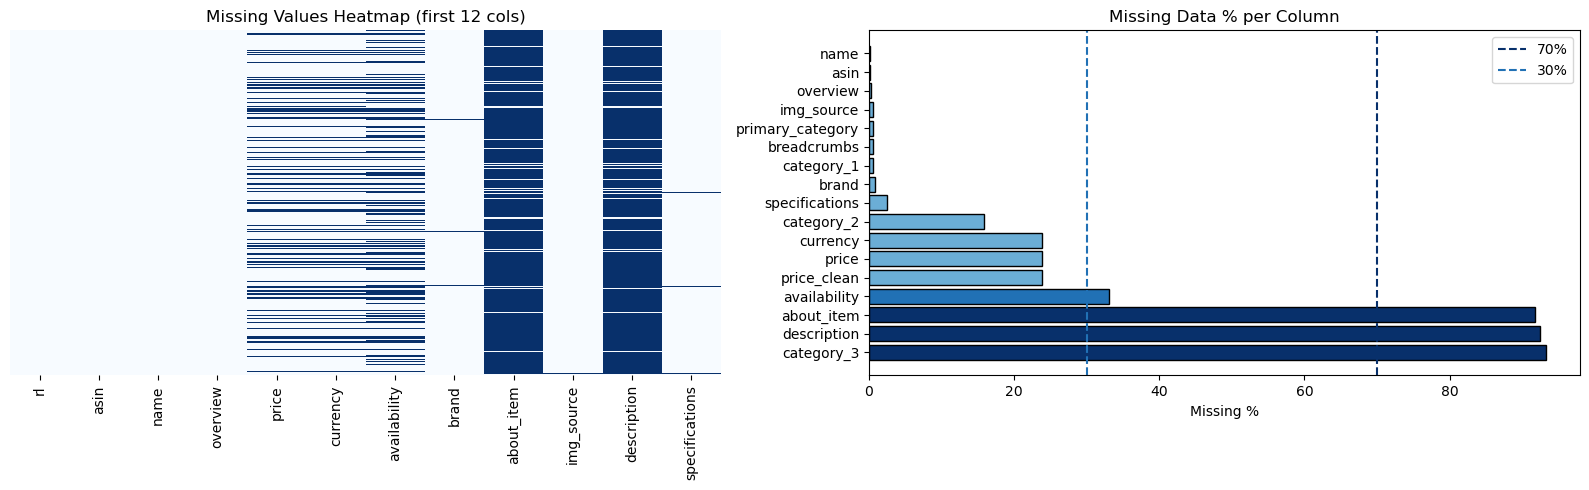

                  Missing Count  Missing Pct
category_3                 1350         93.3
description                1338         92.5
about_item                 1327         91.7
availability                479         33.1
price_clean                 346         23.9
price                       345         23.8
currency                    345         23.8
category_2                  228         15.8
specifications               36          2.5
brand                        11          0.8
category_1                    7          0.5
breadcrumbs                   7          0.5
primary_category              7          0.5
img_source                    7          0.5
overview                      4          0.3
asin                          1          0.1
name                          2          0.1


In [6]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap en paleta azul
sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]

# Diferentes tonos de azul según porcentaje de missing
colors_mv = [
    '#08306b' if v > 70 else    # azul oscuro
    '#2171b5' if v > 30 else    # azul medio
    '#6baed6'                   # azul claro
    for v in mv['Missing Pct']
]

axes[1].barh(
    mv.index,
    mv['Missing Pct'],
    color=colors_mv,
    edgecolor='black'
)

axes[1].axvline(70, color='#08306b', linestyle='--', label='70%')
axes[1].axvline(30, color='#2171b5', linestyle='--', label='30%')

axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingenieria de Caracteristicas (Feature Engineering) <a id='s3'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Ejemplo cotidiano:</b><br>
Un agente inmobiliario no solo utiliza los metros cuadradod brutos, sino tambien considera la ubicaciónm la antiguedad y el estado. Nosotros hacemos lo mismo: extraemos la informacion más valiosa del txto sin procesar categorias
</div>

In [7]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

# print(f'✅ Total Caracteriscas (Atributos) Procesadas (Features Engineered): {len(df.columns)}')
print('\nPrecio por cada tipo (tier) de distribucion:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


Precio por cada tipo (tier) de distribucion:
price_tier
1_budget     104
2_low        287
3_mid        322
4_premium    261
5_luxury     127
Unknown      346


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis Univariado <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Pregunta clave:</b><br>
Aparecen productos con precios muy superiores al resto
Estos puntos están fuera del rango normal definido por el método IQR
Representan productos premium o casos extremos dentro del catálogo
</div>

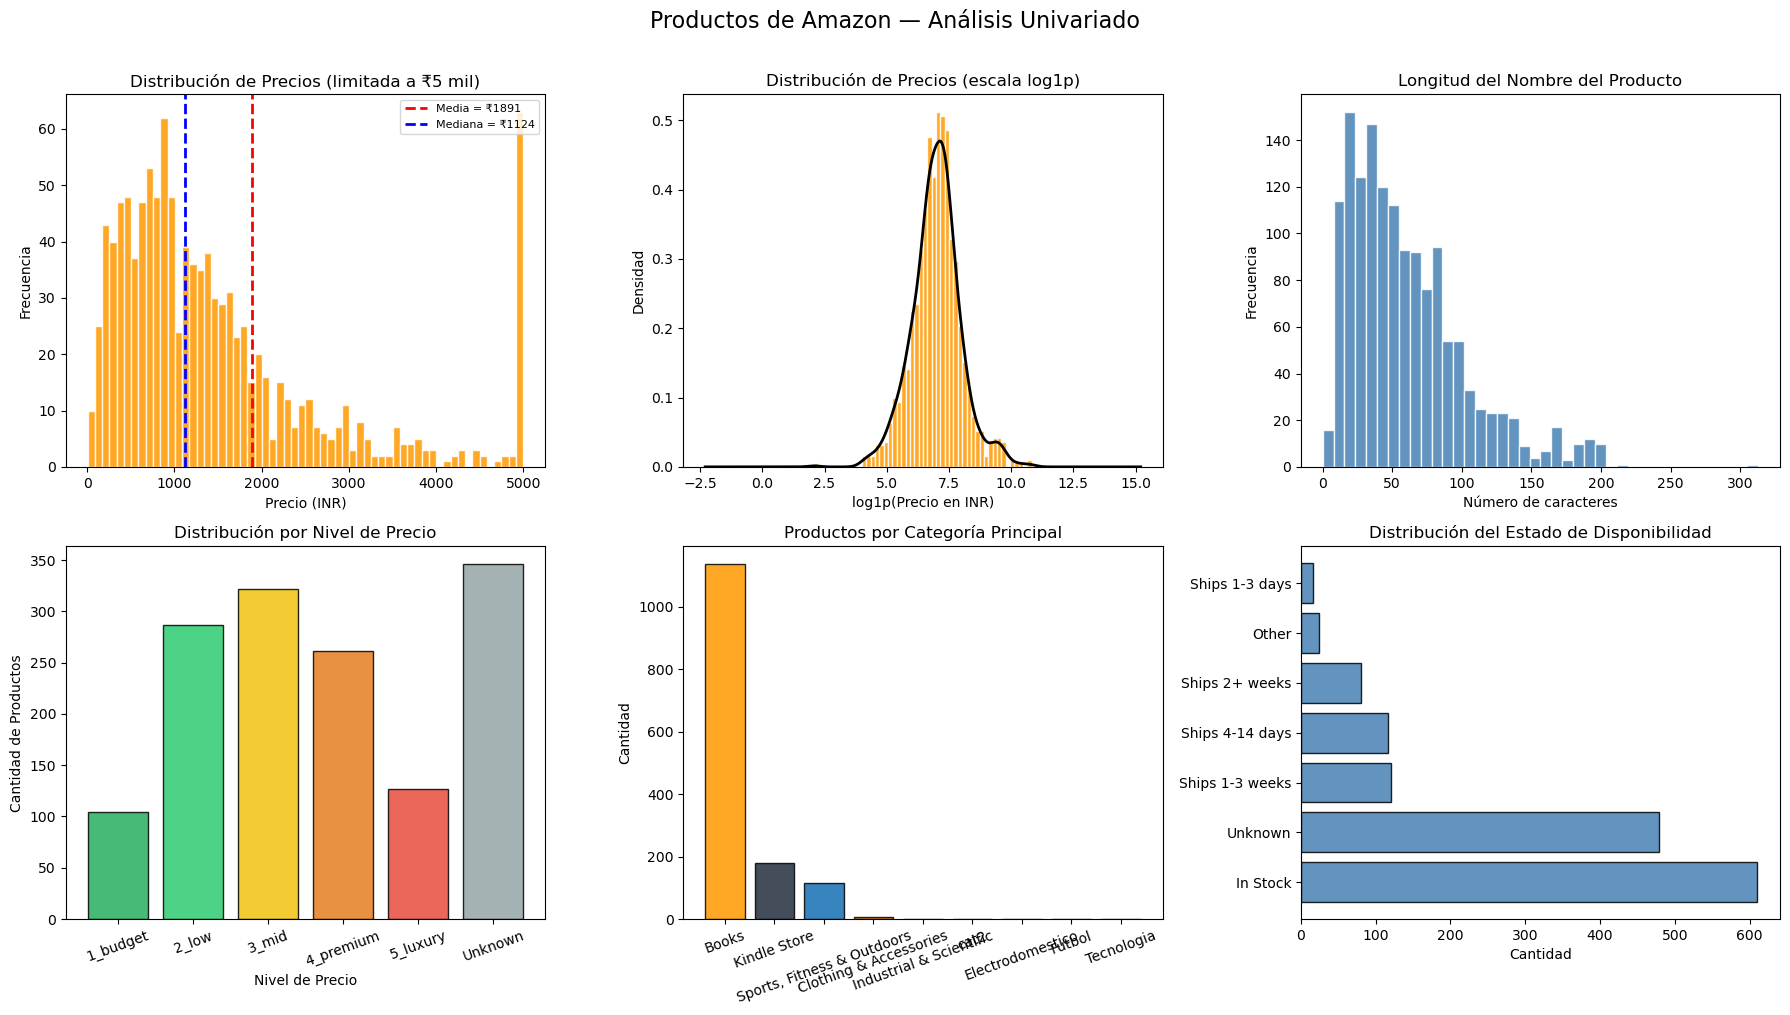

Prueba Shapiro-Wilk (precio logarítmico, n=500): estadístico=0.9853, valor-p=0.000061
El precio sigue sin presentar una distribución normal después de la transformación logarítmica

Estadísticas descriptivas del precio (INR):
count     1094.00
mean      1891.10
std       3360.25
min          7.00
25%        614.29
50%       1123.50
75%       1850.00
max      50555.00


In [15]:
# ============================================================
# SECCIÓN 4 — Análisis Univariado
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distribución del precio original
axes[0,0].hist(
    df_priced['price_clean'].clip(upper=5000),
    bins=60,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85
)

axes[0,0].axvline(
    df_priced['price_clean'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Media = ₹{df_priced["price_clean"].mean():.0f}'
)

axes[0,0].axvline(
    df_priced['price_clean'].median(),
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Mediana = ₹{df_priced["price_clean"].median():.0f}'
)

axes[0,0].set_title('Distribución de Precios (limitada a ₹5 mil)')
axes[0,0].set_xlabel('Precio (INR)')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend(fontsize=8)

# Distribución logarítmica del precio
axes[0,1].hist(
    df_priced['log_price'],
    bins=50,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

df_priced['log_price'].plot.kde(
    ax=axes[0,1],
    color='black',
    lw=2
)

axes[0,1].set_title('Distribución de Precios (escala log1p)')
axes[0,1].set_xlabel('log1p(Precio en INR)')
axes[0,1].set_ylabel('Densidad')

# Longitud del nombre del producto
axes[0,2].hist(
    df['name_length'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

axes[0,2].set_title('Longitud del Nombre del Producto')
axes[0,2].set_xlabel('Número de caracteres')
axes[0,2].set_ylabel('Frecuencia')

# Distribución por nivel de precio
tier_counts = df['price_tier'].value_counts().sort_index()

tier_colors = [
    '#27ae60',
    '#2ecc71',
    '#f1c40f',
    '#e67e22',
    '#e74c3c',
    '#95a5a6'
]

axes[1,0].bar(
    tier_counts.index,
    tier_counts.values,
    color=tier_colors[:len(tier_counts)],
    edgecolor='black',
    alpha=0.85
)

axes[1,0].set_title('Distribución por Nivel de Precio')
axes[1,0].set_xlabel('Nivel de Precio')
axes[1,0].set_ylabel('Cantidad de Productos')
axes[1,0].tick_params(axis='x', rotation=20)

# Categoría principal
cat_counts = df['primary_category'].value_counts()

axes[1,1].bar(
    cat_counts.index,
    cat_counts.values,
    color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
    edgecolor='black',
    alpha=0.85
)

axes[1,1].set_title('Productos por Categoría Principal')
axes[1,1].set_ylabel('Cantidad')
axes[1,1].tick_params(axis='x', rotation=20)

# Disponibilidad
avail_counts = df['avail_clean'].value_counts()

axes[1,2].barh(
    avail_counts.index,
    avail_counts.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1,2].set_title('Distribución del Estado de Disponibilidad')
axes[1,2].set_xlabel('Cantidad')

plt.suptitle(
    'Productos de Amazon — Análisis Univariado',
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

# Prueba de normalidad
stat, p = shapiro(
    df_priced['log_price'].sample(
        min(500, len(df_priced)),
        random_state=42
    )
)

print(
    f'Prueba Shapiro-Wilk (precio logarítmico, n=500): '
    f'estadístico={stat:.4f}, valor-p={p:.6f}'
)

print(
    f'El precio {"presenta una distribución normal después de la transformación logarítmica" if p > 0.05 else "sigue sin presentar una distribución normal después de la transformación logarítmica"}'
)

print('\nEstadísticas descriptivas del precio (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

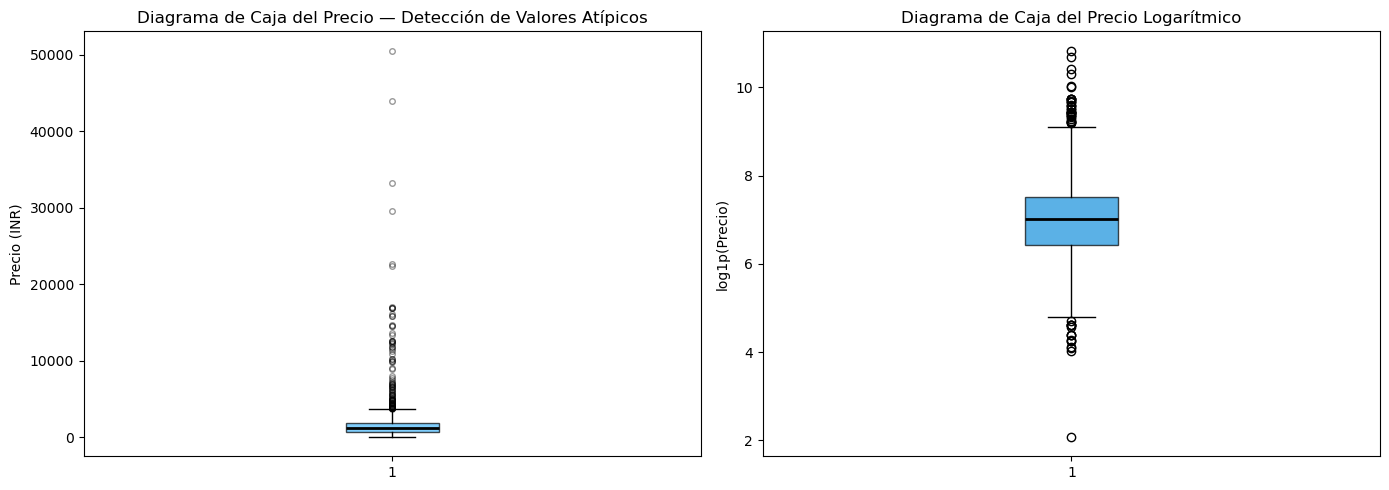

Valores atípicos detectados mediante el método IQR: 94 (8.6%)
Rango de precios (sin valores atípicos): ₹-1239 – ₹3704

Los 10 productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graph

In [12]:
# Análisis de valores atípicos — diagrama de caja e IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    df_priced['price_clean'],
    patch_artist=True,
    boxprops=dict(facecolor='#4BB8FA', alpha=0.7),
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red')
)

axes[0].set_title('Diagrama de Caja del Precio — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR)')

axes[1].boxplot(
    df_priced['log_price'],
    patch_artist=True,
    boxprops=dict(facecolor='#1591DC', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

axes[1].set_title('Diagrama de Caja del Precio Logarítmico')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1

outliers = df_priced[
    (df_priced['price_clean'] < Q1 - 1.5 * IQR) |
    (df_priced['price_clean'] > Q3 + 1.5 * IQR)
]

print(f'Valores atípicos detectados mediante el método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Rango de precios (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')

print(f'\nLos 10 productos más caros:')
print(
    df_priced.nlargest(10, 'price_clean')[
        ['name', 'price_clean', 'primary_category']
    ].to_string(index=False)
)

## 6. Análisis de categorías <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Ejemplo cotidiano:</b><br>
El gráfico de cajas (boxplot) confirma esto mostrando que algunas categorías no solo tienen precios más altos en promedio, sino también una mayor dispersión, con productos premium o outliers que elevan el rango.
</div>

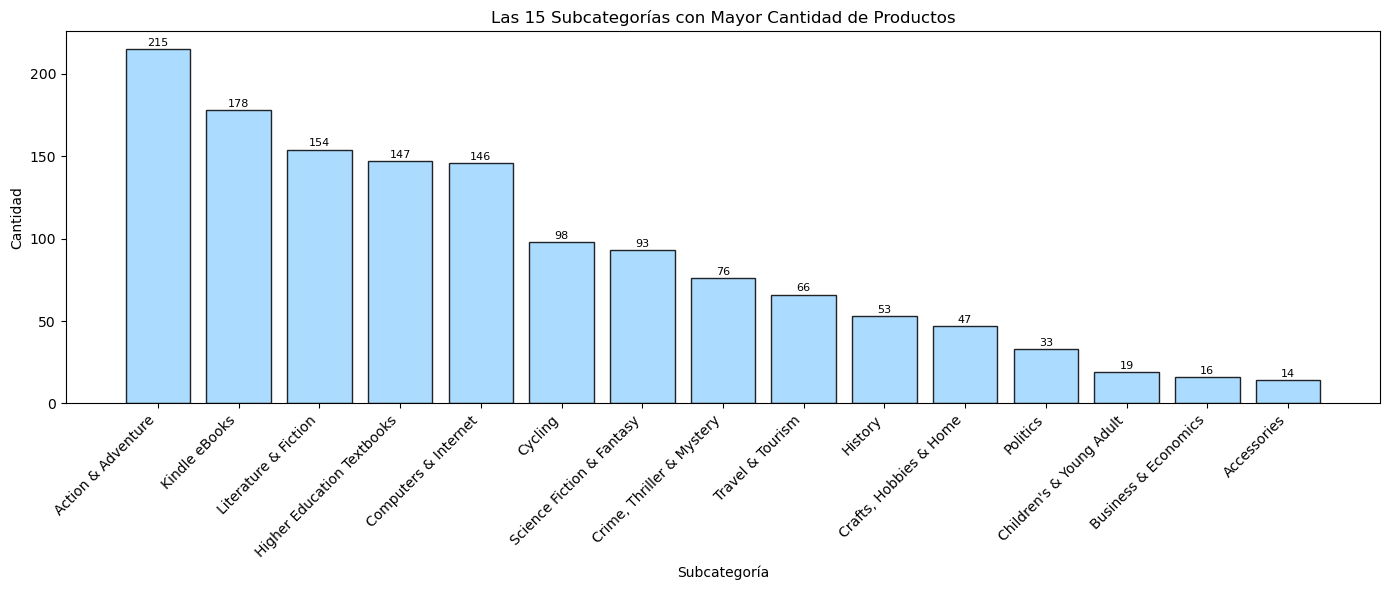

In [18]:
# ============================================================
# SECCIÓN 5 — Análisis de Categorías
# ============================================================

# Top 15 subcategorías con mayor cantidad de productos
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))

bars = plt.bar(
    top15_cat1.index,
    top15_cat1.values,
    color='#9CD5FF',
    edgecolor='black',
    alpha=0.85
)

for bar, val in zip(bars, top15_cat1.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        str(val),
        ha='center',
        fontsize=8
    )

plt.title('Las 15 Subcategorías con Mayor Cantidad de Productos')
plt.xlabel('Subcategoría')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

C:\Users\PC-16\AppData\Local\Temp\ipykernel_16168\4153434319.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


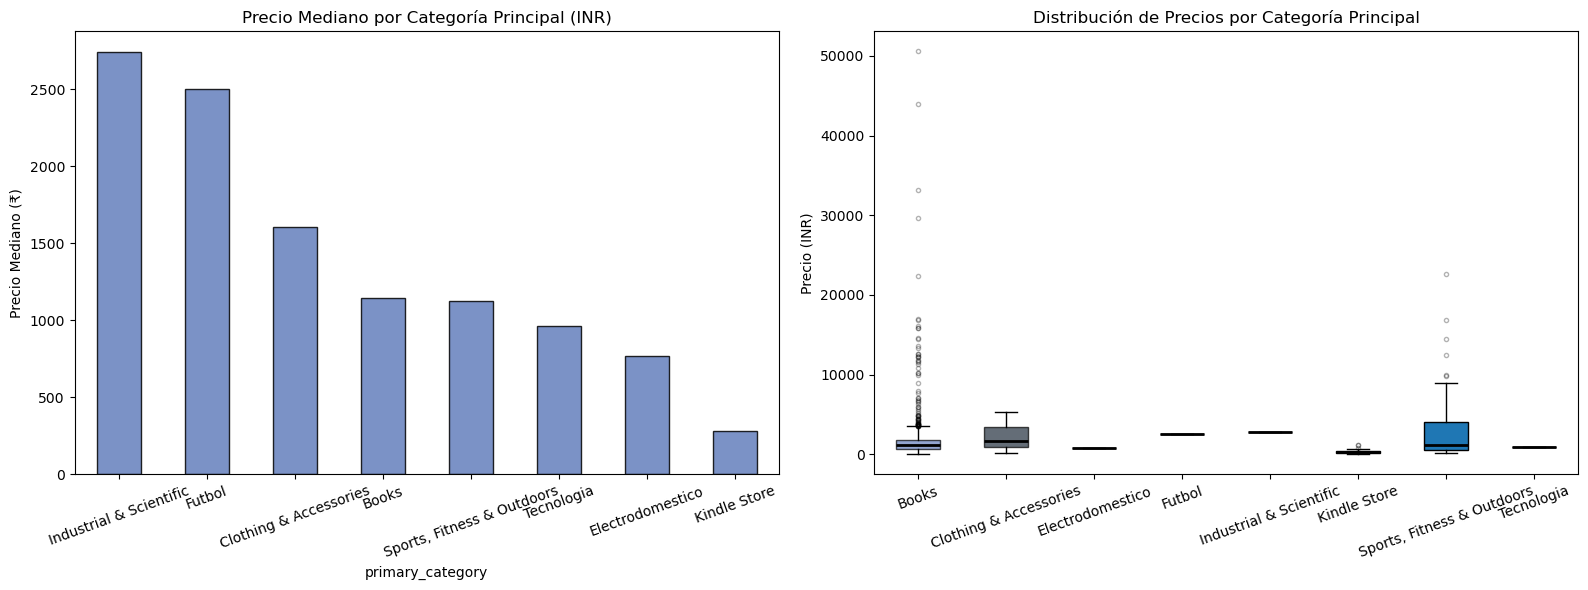

Estadísticas de precios por categoría principal:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Electrodomestico             769.0   769.0      1
Futbol                      2500.0  2500.0      1
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93
Tecnologia                   959.4   959.4      1


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)

cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0],
    color='#647FBC',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Precio Mediano por Categoría Principal (INR)')
axes[0].set_ylabel('Precio Mediano (₹)')
axes[0].tick_params(axis='x', rotation=20)

# Diagrama de caja
cat_groups = [
    df_priced[df_priced['primary_category'] == c]['price_clean'].dropna()
    for c in cat_price.index
]

bp = axes[1].boxplot(
    cat_groups,
    labels=cat_price.index,
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

colors_cat = ['#647FBC','#232F3E','#146EB4','#E47911','#999']

for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Distribución de Precios por Categoría Principal')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Estadísticas de precios por categoría principal:')
print(cat_price.to_string())

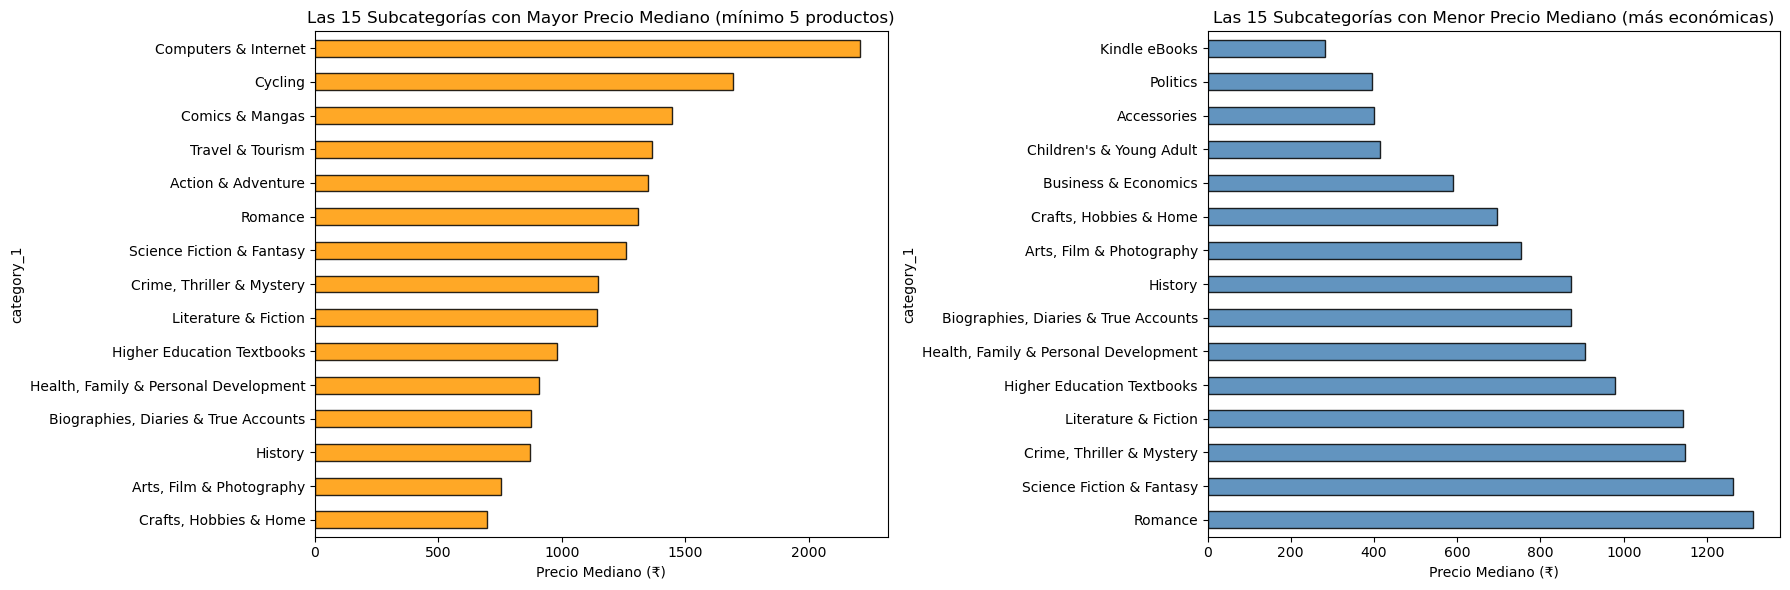

In [22]:
# Top 15 subcategorías por precio mediano
top_cat1_price = (
    df_priced.groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Las 15 Subcategorías con Mayor Precio Mediano (mínimo 5 productos)')
axes[0].set_xlabel('Precio Mediano (₹)')

# Las 15 subcategorías más económicas
bottom_cat1 = (
    df_priced.groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median')
    .head(15)
)

bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1],
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Las 15 Subcategorías con Menor Precio Mediano (más económicas)')
axes[1].set_xlabel('Precio Mediano (₹)')

plt.tight_layout()
plt.show()

## 7. Análisis de disponibilidad <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Pregunta Clave:</b><br>
Son las 15 subcategorías que aparecen con mayor frecuencia en la variable category_1, es decir, las que tienen más registros en el dataset.
</div>

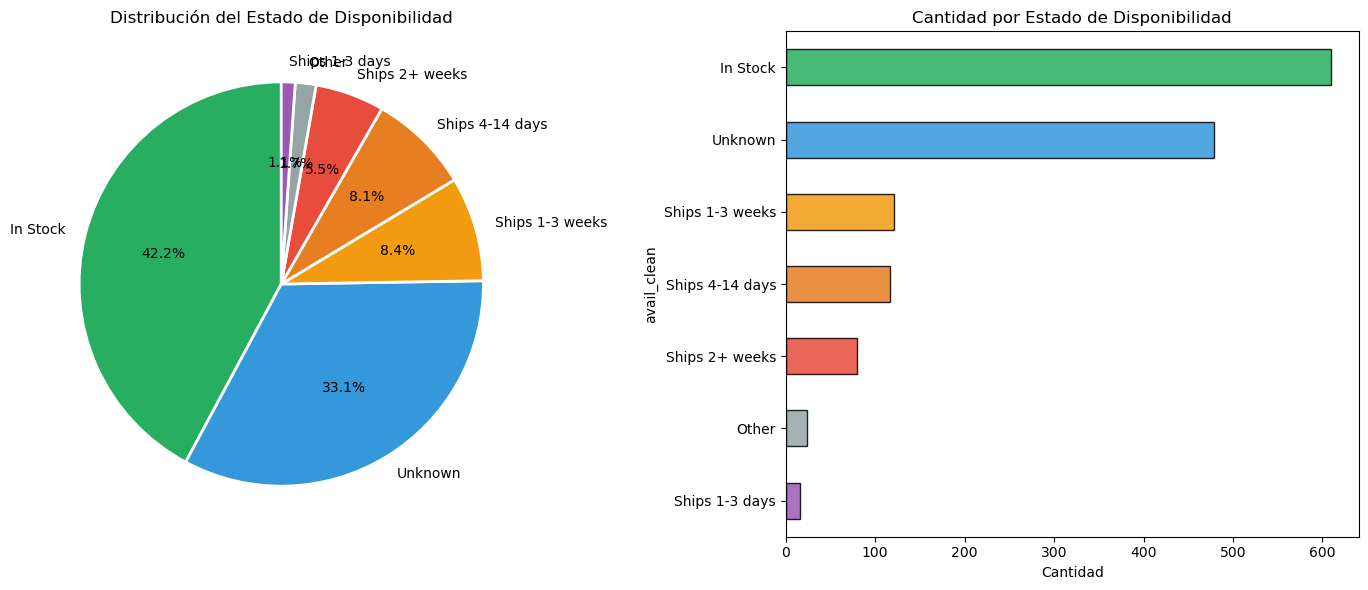

In [23]:
# ============================================================
# SECCIÓN 6 — Análisis de Disponibilidad
# ============================================================

avail_counts = df['avail_clean'].value_counts()

avail_colors = [
    '#27ae60',
    '#3498db',
    '#f39c12',
    '#e67e22',
    '#e74c3c',
    '#95a5a6',
    '#9b59b6',
    '#1abc9c'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(
    avail_counts.values,
    labels=avail_counts.index,
    colors=avail_colors[:len(avail_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

axes[0].set_title('Distribución del Estado de Disponibilidad')

avail_counts.sort_values().plot.barh(
    ax=axes[1],
    color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Cantidad por Estado de Disponibilidad')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

C:\Users\PC-16\AppData\Local\Temp\ipykernel_16168\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


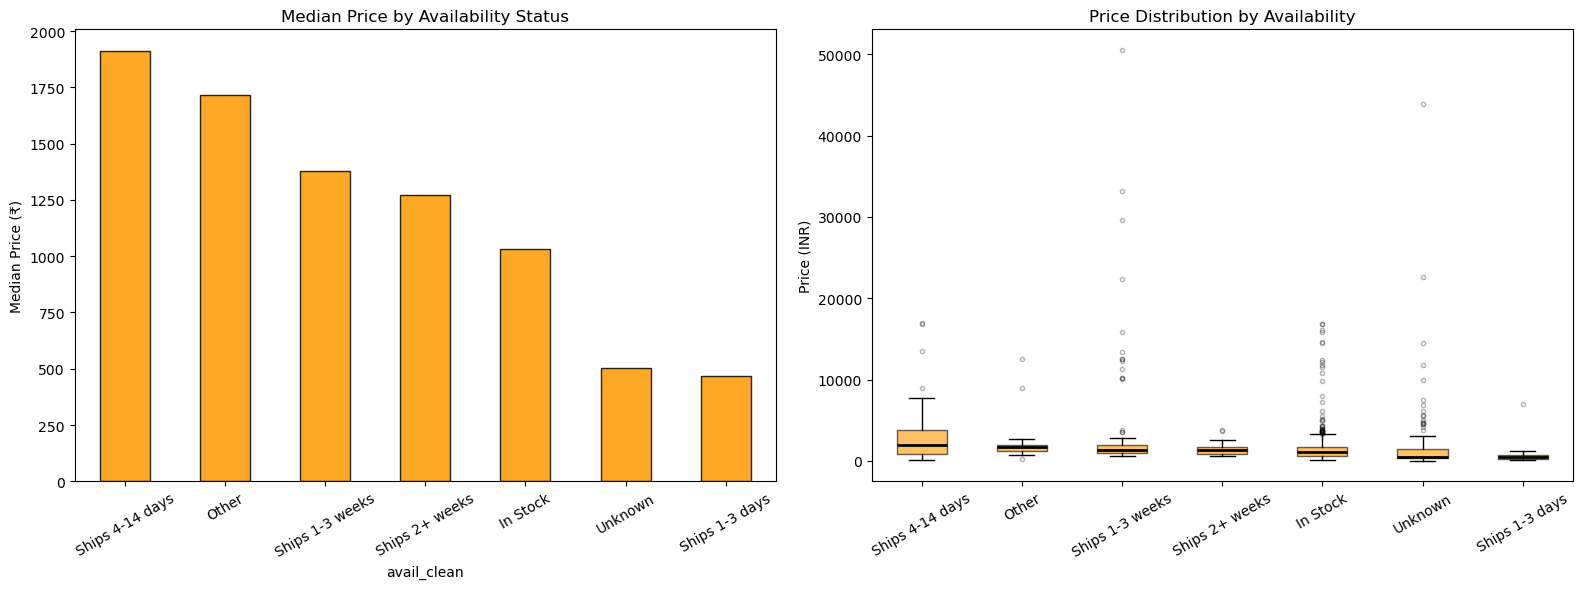

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2858.2    117
Other            1718.0  2322.4     23
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.5  1514.0    602
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [24]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

## 8. Correlación y análisis bivariado <a id='s8'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Pregunta Clave:</b><br>
Los productos de categorías Premium o Luxury podrían agotarse con mayor frecuencia debido a que suelen manejar inventarios más limitados.
Alternativamente, los productos económicos podrían agotarse más porque tienen una mayor rotación de ventas.
</div>

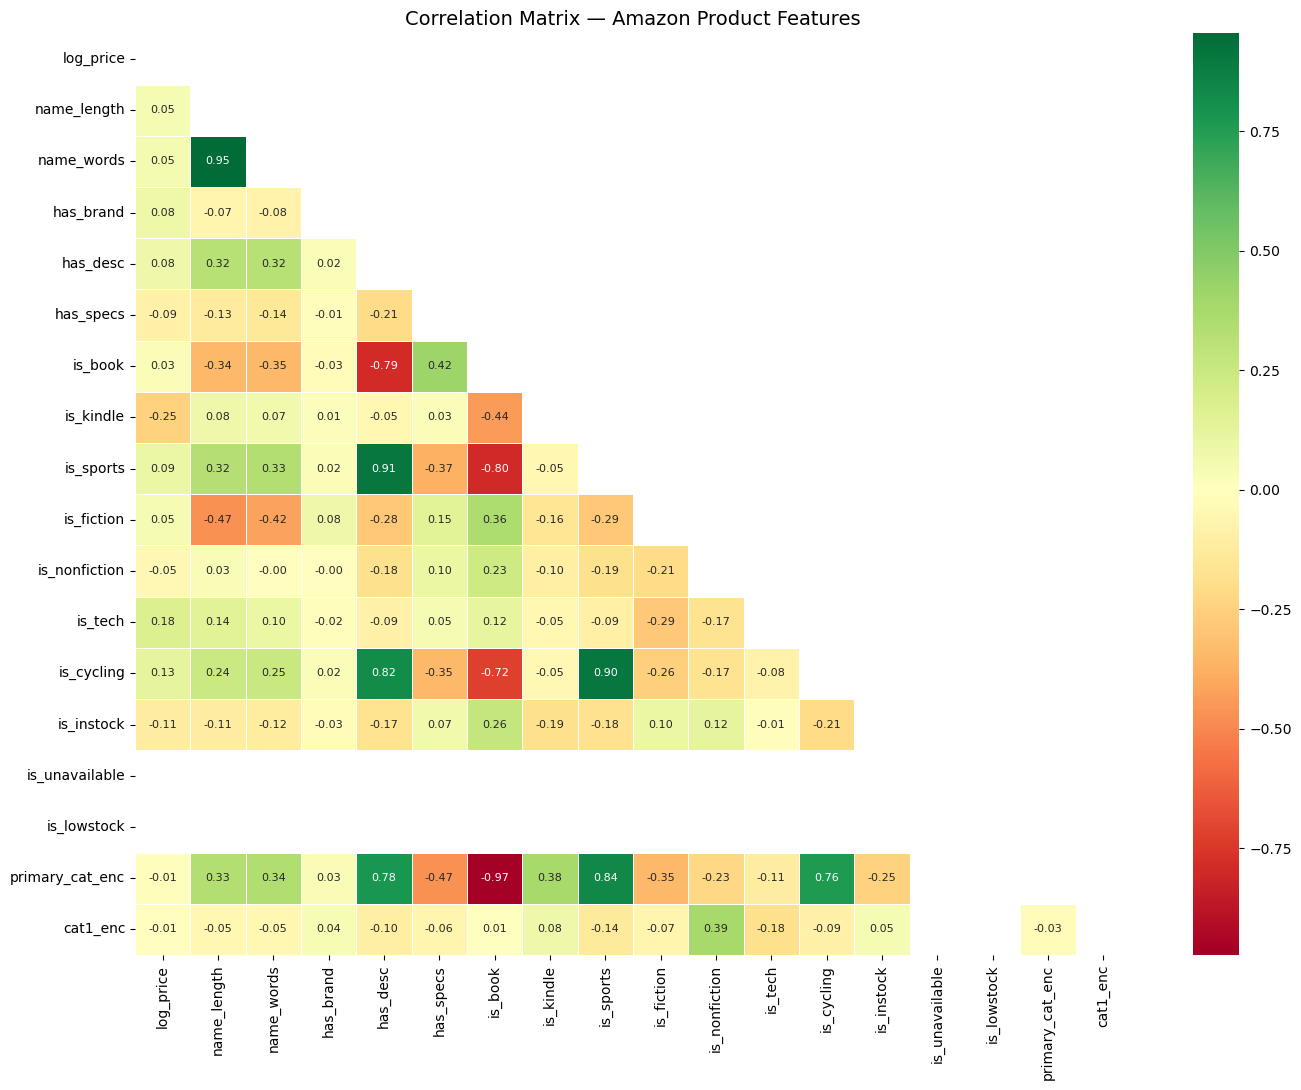

Top correlations with log_price:
is_tech            0.175117
is_cycling         0.125443
is_sports          0.090623
has_brand          0.083619
has_desc           0.079685
name_words         0.053568
is_fiction         0.050095
name_length        0.048293
is_book            0.027009
cat1_enc          -0.006615
primary_cat_enc   -0.009345
is_nonfiction     -0.045720
has_specs         -0.085469
is_instock        -0.111997
is_kindle         -0.245971
is_unavailable          NaN
is_lowstock             NaN


In [25]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

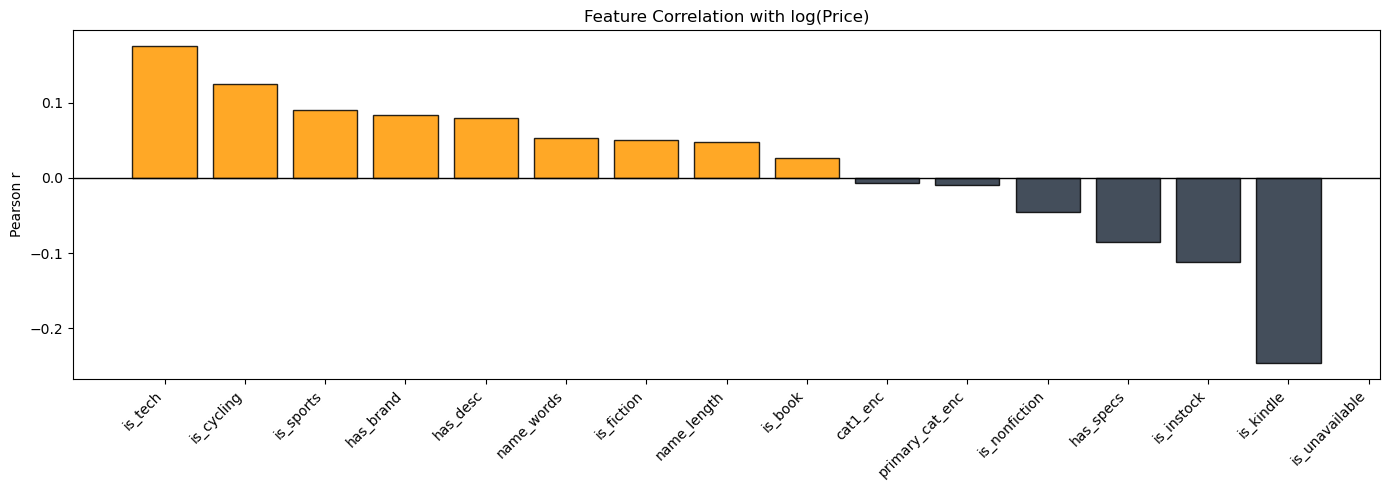

In [26]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()